Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data: 590
Rows kept after file existence filtering: 389
Rows removed: 201

Sample rows:
           sample_uid                          ELHPath  Make make_plot  \
0  3903_35_1_01272020  ./EL/3903_35_1_01272020_80.tiff    35        35   
1  3887_35_1_01272020  ./EL/3887_35_1_01272020_80.tiff    35        35   
2  3887_35_1_02222021  ./EL/3887_35_1_02222021_80.tiff    35        35   
3  3899_35_1_01272020  ./EL/3899_35_1_01272020_80.tiff    35        35   
4  3899_35_1_02222021  ./EL/3899_35_1_02222021_80.tiff    35        35   

                                           high_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno... 

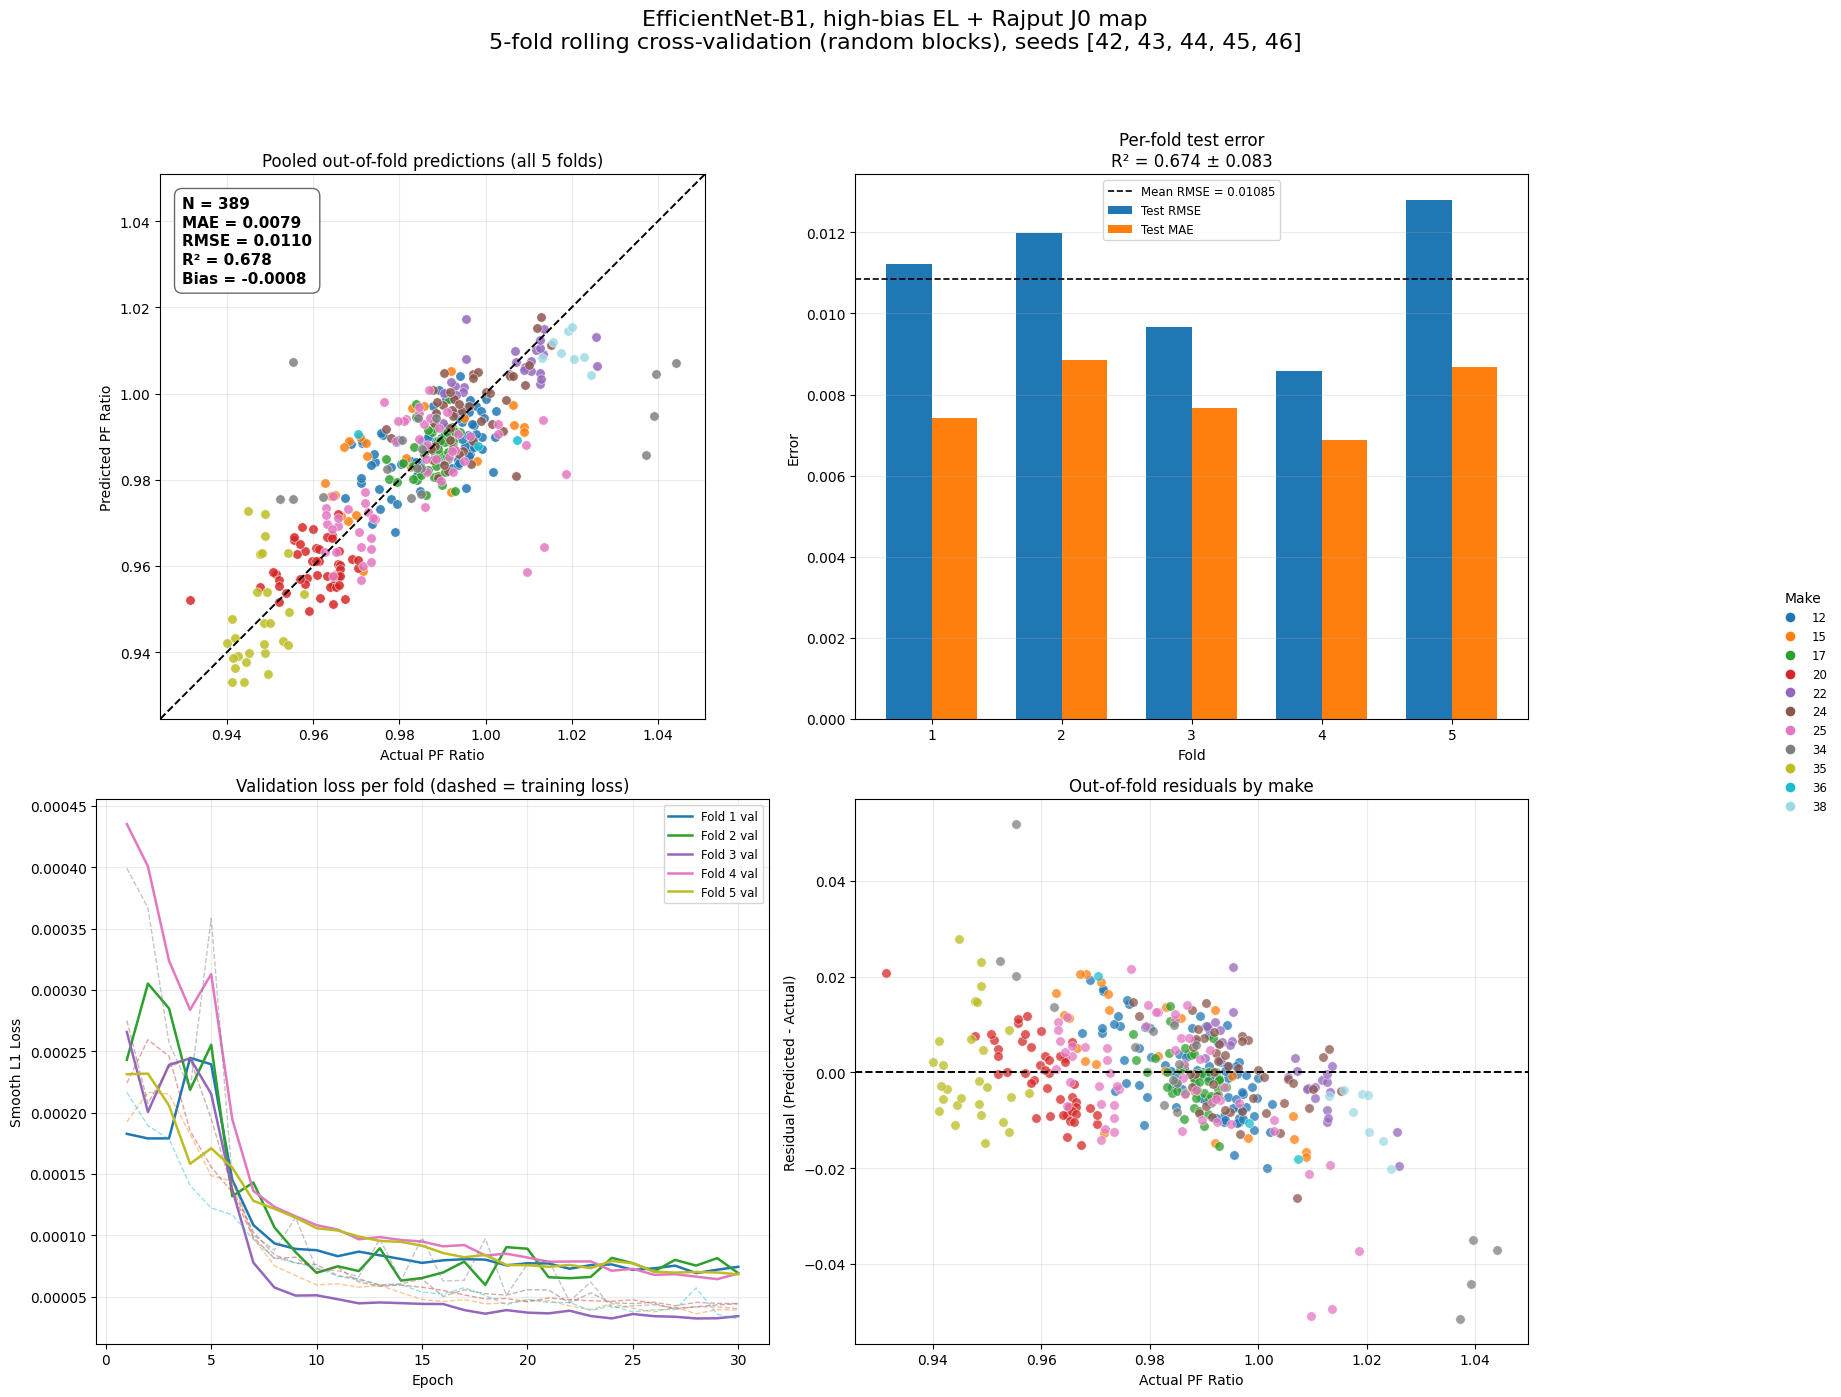


Saved:
- cv5_effnet_b1_highbias_j0_fold_assignments.csv
- cv5_effnet_b1_highbias_j0_config.json
- cv5_effnet_b1_highbias_j0_cv_summary.png
- cv5_effnet_b1_highbias_j0_per_fold_metrics.csv
- cv5_effnet_b1_highbias_j0_summary_metrics.csv
- cv5_effnet_b1_highbias_j0_oof_test_predictions.csv
- cv5_effnet_b1_highbias_j0_all_validation_predictions.csv
- cv5_effnet_b1_highbias_j0_training_history.csv
- cv5_effnet_b1_highbias_j0_oof_metrics_per_make.csv
- cv5_effnet_b1_highbias_j0_fold1..5_best_val_model.pth
Cleanup done.


In [1]:
"""
5-fold rolling cross-validation
EfficientNet-B1, 2-channel input: high-bias EL + Rajput J0 map

Key properties
--------------
1. All images and J0 maps are read from disk and resized ONCE into a single
   RAM cache. Every fold reuses that cache by index, so there is no repeated
   file I/O between folds.

2. Rolling fold scheme with 5 blocks B0..B4:
       fold 1: test = B0, val = B1, train = B2,B3,B4
       fold 2: test = B1, val = B2, train = B3,B4,B0
       fold 3: test = B2, val = B3, train = B4,B0,B1
       fold 4: test = B3, val = B4, train = B0,B1,B2
       fold 5: test = B4, val = B0, train = B1,B2,B3
   Every module is used exactly once as a test sample, so the pooled
   out-of-fold (OOF) prediction set covers the whole dataset.

3. The block partition is controlled by FOLD_ASSIGNMENT_SEED and is written to
   a CSV. The training seed varies per fold (TRAINING_SEEDS) and only affects
   weight init, augmentation and batch order, never the split.

4. J0 normalization limits are recomputed from the TRAIN subset of each fold
   only. The cache stores raw (unnormalized) J0, so this is leak-free and fast.

Reusing the folds for the high-bias-only experiment
---------------------------------------------------
Run this script once. It writes:

    cv5_fold_assignments.csv

with columns sample_uid, ELHPath, Make, pf_ratio, block, fold_1_split ...
fold_5_split. In the high-bias-only script, read that CSV and select rows with
fold_k_split == "train"/"val"/"test" for fold k. Same modules, same splits,
same seeds, so the two input representations are directly comparable.
"""

import os
import math
import copy
import random
import time
import gc
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"

PHYSICS_MAP_DIR = "J0_Rs"

IMAGE_SIZE = 240
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
NUM_WORKERS = 0

# ---- Cross-validation settings ----
N_FOLDS = 5

# Controls the block partition ONLY. Keep this fixed so the high-bias-only
# experiment can reuse identical folds.
FOLD_ASSIGNMENT_SEED = 42

# Training seed per fold: weight init, augmentation, batch order.
TRAINING_SEEDS = [42, 43, 44, 45, 46]

# Set to None for a plain random block partition (matches the previous
# random 80/10/10 protocol).
# Set to "Make" (or a model-level column, if you have one) for a group-aware
# partition, where all modules of a manufacturer land in the same block. This
# removes manufacturer-level leakage and usually lowers R2 substantially, but
# it is the honest generalization number.
GROUP_COLUMN = None

# Require a Rajput J0 map to exist. Keep True so the high-bias-only run uses
# exactly the same module population and the comparison is like-for-like.
REQUIRE_J0_MAP = True

J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

OUTPUT_PREFIX = "cv5_effnet_b1_highbias_j0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


def derive_sample_uid(elh_path_str):
    """Stable join key shared with the high-bias-only script."""
    if pd.isna(elh_path_str):
        return None

    filename = os.path.basename(str(elh_path_str).strip())
    name, _ = os.path.splitext(filename)
    return name.rsplit("_", 1)[0]


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)", MAKE_COLUMN]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]
    df["sample_uid"] = df["ELHPath"].apply(derive_sample_uid)

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )
    df["j0_path"] = df["ELHPath"].apply(lambda p: derive_j0_path(p, base_dir))

    df = df[df["high_path"].notna()].copy()
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    df["j0_exists"] = df["j0_path"].apply(
        lambda p: bool(p) and os.path.exists(p)
    )

    total_before = len(df)

    if REQUIRE_J0_MAP:
        df = df[df["high_exists"] & df["j0_exists"]].copy()
    else:
        df = df[df["high_exists"]].copy()

    print(f"Rows with valid power data: {total_before}")
    print(f"Rows kept after file existence filtering: {len(df)}")
    print(f"Rows removed: {total_before - len(df)}")

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        "sample_uid",
        "ELHPath",
        MAKE_COLUMN,
        "make_plot",
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# FOLD CONSTRUCTION
# =========================================================
def build_rolling_blocks(df, n_folds, fold_seed, group_column=None):
    """
    Assign every row to one of n_folds blocks.

    group_column=None  -> random balanced blocks
    group_column set   -> all rows of a group go to the same block, blocks
                          balanced greedily by sample count
    """
    n = len(df)
    rng = np.random.default_rng(fold_seed)
    block_of_row = np.full(n, -1, dtype=int)

    if group_column is None:
        order = rng.permutation(n)
        for b, idx in enumerate(np.array_split(order, n_folds)):
            block_of_row[idx] = b
        return block_of_row

    if group_column not in df.columns:
        raise ValueError(f"GROUP_COLUMN '{group_column}' not present in dataframe.")

    groups = df[group_column].fillna("Unknown").astype(str).to_numpy()
    uniq, counts = np.unique(groups, return_counts=True)

    # shuffle first so equal-sized groups are not always assigned in the
    # same alphabetical order, then fill largest-first
    perm = rng.permutation(len(uniq))
    uniq, counts = uniq[perm], counts[perm]
    order = np.argsort(-counts, kind="stable")

    load = np.zeros(n_folds, dtype=int)
    group_to_block = {}

    for gi in order:
        b = int(np.argmin(load))
        group_to_block[uniq[gi]] = b
        load[b] += int(counts[gi])

    for i in range(n):
        block_of_row[i] = group_to_block[groups[i]]

    print("\nGroup-aware block sizes:", load.tolist())
    return block_of_row


def fold_indices(block_of_row, fold_index, n_folds):
    """fold_index is 0-based. test = block k, val = block k+1, train = rest."""
    test_block = fold_index
    val_block = (fold_index + 1) % n_folds

    test_idx = np.where(block_of_row == test_block)[0]
    val_idx = np.where(block_of_row == val_block)[0]
    train_idx = np.where(
        (block_of_row != test_block) & (block_of_row != val_block)
    )[0]

    return train_idx, val_idx, test_idx


def build_fold_assignment_table(df, block_of_row, n_folds):
    table = df[["sample_uid", "ELHPath", MAKE_COLUMN, "pf_ratio"]].copy()
    table["block"] = block_of_row

    for k in range(n_folds):
        train_idx, val_idx, test_idx = fold_indices(block_of_row, k, n_folds)

        col = np.empty(len(df), dtype=object)
        col[train_idx] = "train"
        col[val_idx] = "val"
        col[test_idx] = "test"

        table[f"fold_{k + 1}_split"] = col
        table[f"fold_{k + 1}_seed"] = TRAINING_SEEDS[k]

    return table


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")
    return img


def read_physics_map(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)
    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def _resize_with_padding(img, target_size, dtype):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=dtype)
    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_uint8(img, target_size=240):
    return _resize_with_padding(img, target_size, np.uint8)


def resize_with_padding_float(img, target_size=240):
    return _resize_with_padding(img, target_size, np.float32)


J0_FLOOR = 1e-20


def compute_j0_limits_from_cache(
    cache_j0,
    train_indices,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
    seed=42,
):
    """
    Robust log-domain J0 limits from the TRAIN subset of this fold only.
    Operates on the RAM cache, so no file re-reading between folds.
    """
    all_log_values = []
    rng = np.random.default_rng(seed)

    for i in train_indices:
        j0_resized = cache_j0[i]
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in this fold's train set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(
        f"  log10(J0) p{lower_percentile:g} = {log_lower:.4f} "
        f"({10 ** log_lower:.3e} A/px) | "
        f"p{upper_percentile:g} = {log_upper:.4f} "
        f"({10 ** log_upper:.3e} A/px) | "
        f"active px = {all_log_values.size:,}"
    )

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10 ** log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# MASTER RAM CACHE (loaded once, shared by all folds)
# =========================================================
class MasterCache:
    def __init__(self, dataframe, image_size=240):
        self.image_size = image_size
        n = len(dataframe)

        expected_mb = (
            n * image_size * image_size * 1 + n * image_size * image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM (once, shared by all folds)...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.high = np.empty((n, image_size, image_size), dtype=np.uint8)
        self.j0 = np.empty((n, image_size, image_size), dtype=np.float32)
        self.pf = dataframe["pf_ratio"].to_numpy(dtype=np.float32)

        failed = 0

        for i in range(n):
            row = dataframe.iloc[i]
            try:
                self.high[i] = resize_with_padding_uint8(
                    read_high_bias_image(row["high_path"]), image_size
                )
                self.j0[i] = resize_with_padding_float(
                    read_physics_map(row["j0_path"]), image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.high[i] = 0
                self.j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.high.nbytes + self.j0.nbytes) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}"
        )


class FoldSubsetDataset(Dataset):
    """Views into the master cache. No file I/O, no image copies at build time."""

    def __init__(self, master, indices, augment=False, j0_norm_params=None):
        self.master = master
        self.indices = np.asarray(indices, dtype=int)
        self.augment = augment
        self.j0_norm_params = j0_norm_params

        if j0_norm_params is None:
            raise ValueError("j0_norm_params must be provided for each fold.")

    def __len__(self):
        return len(self.indices)

    def apply_same_augmentation(self, high_img, j0_map):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __getitem__(self, i):
        idx = self.indices[i]

        high_img = self.master.high[idx].copy()
        j0_map = self.master.j0[idx].copy()

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        high_img = high_img.astype(np.float32) / 255.0
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        x = np.concatenate(
            [np.expand_dims(high_img, 0), np.expand_dims(j0_map, 0)], axis=0
        )
        y = float(self.master.pf[idx])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# ONE FOLD
# =========================================================
def run_one_fold(fold_index, df, master, block_of_row):
    fold_number = fold_index + 1
    seed = TRAINING_SEEDS[fold_index]

    train_idx, val_idx, test_idx = fold_indices(block_of_row, fold_index, N_FOLDS)

    print(f"\n{'=' * 78}")
    print(f"FOLD {fold_number}/{N_FOLDS} | training seed = {seed}")
    print(
        f"test block = {fold_index} ({len(test_idx)}) | "
        f"val block = {(fold_index + 1) % N_FOLDS} ({len(val_idx)}) | "
        f"train ({len(train_idx)})"
    )
    print(f"{'=' * 78}")

    if min(len(train_idx), len(val_idx), len(test_idx)) == 0:
        raise ValueError(f"Fold {fold_number} has an empty split.")

    set_seed(seed)

    j0_norm_params = compute_j0_limits_from_cache(
        master.j0,
        train_idx,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
        seed=seed,
    )

    train_dataset = FoldSubsetDataset(master, train_idx, True, j0_norm_params)
    val_dataset = FoldSubsetDataset(master, val_idx, False, j0_norm_params)
    test_dataset = FoldSubsetDataset(master, test_idx, False, j0_norm_params)

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    history = []
    t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, _, _, _, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, _, _, _, _, _ = evaluate(model, test_loader, criterion, DEVICE)

        scheduler.step(val_loss)

        history.append(
            {
                "fold": fold_number,
                "seed": seed,
                "epoch": epoch + 1,
                "train_loss": train_eval_loss,
                "validation_loss": val_loss,
                "test_loss": test_loss,
                "backbone_lr": current_backbone_lr,
                "head_lr": current_head_lr,
            }
        )

        print(
            f"  Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{time.time() - epoch_t0:.1f}s | "
            f"Train {train_eval_loss:.6f} | "
            f"Val {val_loss:.6f} | "
            f"Test {test_loss:.6f} | "
            f"Val MAE {val_mae:.6f} | "
            f"Val RMSE {val_rmse:.6f} | "
            f"Val R2 {val_r2:.4f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f"  Fold time: {time.time() - t0:.1f}s | best epoch: {best_epoch}")

    model.load_state_dict(best_model_wts)

    _, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    _, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(
        f"  VAL  MAE {val_mae:.6f} | RMSE {val_rmse:.6f} | R2 {val_r2:.6f}\n"
        f"  TEST MAE {test_mae:.6f} | RMSE {test_rmse:.6f} | R2 {test_r2:.6f}"
    )

    history_df = pd.DataFrame(history)
    history_df["is_best_epoch"] = history_df["epoch"] == best_epoch

    def prediction_table(indices, trues, preds, split_name):
        table = df.iloc[indices].reset_index(drop=True).copy()
        table["fold"] = fold_number
        table["seed"] = seed
        table["evaluation_split"] = split_name
        table["actual_pf_ratio"] = trues
        table["predicted_pf_ratio"] = preds
        table["residual"] = preds - trues
        table["absolute_error"] = np.abs(preds - trues)
        return table

    test_table = prediction_table(test_idx, test_trues, test_preds, "test")
    val_table = prediction_table(val_idx, val_trues, val_preds, "validation")

    model_path = f"{OUTPUT_PREFIX}_fold{fold_number}_best_val_model.pth"
    torch.save(model.state_dict(), model_path)

    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    fold_metrics = {
        "fold": fold_number,
        "seed": seed,
        "best_epoch": best_epoch,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
        "val_MAE": val_mae,
        "val_RMSE": val_rmse,
        "val_R2": val_r2,
        "test_MAE": test_mae,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "j0_log_lower": j0_norm_params["log_lower"],
        "j0_log_upper": j0_norm_params["log_upper"],
        "model_path": model_path,
    }

    return fold_metrics, history_df, test_table, val_table


# =========================================================
# PLOTTING
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]
    return dict(zip(makes, colours))


def plot_oof_scatter(ax, oof_df, make_palette):
    values = np.concatenate(
        [oof_df["actual_pf_ratio"].to_numpy(), oof_df["predicted_pf_ratio"].to_numpy()]
    )
    minimum, maximum = float(values.min()), float(values.max())
    margin = max((maximum - minimum) * 0.06, 0.003)
    minimum, maximum = minimum - margin, maximum + margin

    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=46,
            color=make_palette[make_value],
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
            label=make_value,
        )

    ax.plot([minimum, maximum], [minimum, maximum], "--", color="black", linewidth=1.4)
    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title("Pooled out-of-fold predictions (all 5 folds)")
    ax.grid(True, alpha=0.25)

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    text = (
        f"N = {len(actual)}\n"
        f"MAE = {mean_absolute_error(actual, predicted):.4f}\n"
        f"RMSE = {math.sqrt(mean_squared_error(actual, predicted)):.4f}\n"
        f"R² = {r2_score(actual, predicted):.3f}\n"
        f"Bias = {np.mean(predicted - actual):+.4f}"
    )

    ax.text(
        0.04, 0.96, text, transform=ax.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold", linespacing=1.3,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.35", alpha=0.9),
    )


def plot_fold_metric_bars(ax, metrics_df):
    folds = metrics_df["fold"].to_numpy()
    width = 0.35

    ax.bar(folds - width / 2, metrics_df["test_RMSE"], width, label="Test RMSE")
    ax.bar(folds + width / 2, metrics_df["test_MAE"], width, label="Test MAE")

    ax.axhline(
        metrics_df["test_RMSE"].mean(), linestyle="--", color="black", linewidth=1.2,
        label=f"Mean RMSE = {metrics_df['test_RMSE'].mean():.5f}",
    )

    ax.set_xticks(folds)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_title(
        "Per-fold test error\n"
        f"R² = {metrics_df['test_R2'].mean():.3f} ± {metrics_df['test_R2'].std(ddof=1):.3f}"
    )
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend(fontsize=8.5)


def plot_all_fold_losses(ax, history_df):
    for fold_number, group in history_df.groupby("fold"):
        ax.plot(
            group["epoch"], group["validation_loss"],
            linewidth=1.8, label=f"Fold {fold_number} val",
        )
        ax.plot(
            group["epoch"], group["train_loss"],
            linewidth=1.0, alpha=0.45, linestyle="--",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Validation loss per fold (dashed = training loss)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8.5)


def plot_oof_residuals(ax, oof_df, make_palette):
    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"], group["residual"],
            color=make_palette[make_value], s=46, alpha=0.75,
            edgecolors="white", linewidths=0.4,
        )

    ax.axhline(0.0, linestyle="--", color="black", linewidth=1.4)
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Out-of-fold residuals by make")
    ax.grid(True, alpha=0.25)


def calculate_metrics_per_make(results_df):
    rows = []
    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < N_FOLDS * 4:
        raise ValueError(f"Only {len(df)} samples available, too few for {N_FOLDS} folds.")

    print("\nSample rows:")
    print(df.head())

    # ---- Folds first, so the assignment CSV exists even if training crashes ----
    block_of_row = build_rolling_blocks(
        df, N_FOLDS, FOLD_ASSIGNMENT_SEED, GROUP_COLUMN
    )

    fold_table = build_fold_assignment_table(df, block_of_row, N_FOLDS)
    fold_csv_path = f"{OUTPUT_PREFIX}_fold_assignments.csv"
    fold_table.to_csv(fold_csv_path, index=False)

    print(f"\nFold assignment written to {fold_csv_path}")
    print("Block sizes:", np.bincount(block_of_row, minlength=N_FOLDS).tolist())

    for k in range(N_FOLDS):
        counts = fold_table[f"fold_{k + 1}_split"].value_counts()
        print(
            f"  Fold {k + 1}: "
            f"train={counts.get('train', 0)}, "
            f"val={counts.get('val', 0)}, "
            f"test={counts.get('test', 0)}, "
            f"seed={TRAINING_SEEDS[k]}"
        )

    config = {
        "csv_path": CSV_PATH,
        "n_folds": N_FOLDS,
        "fold_assignment_seed": FOLD_ASSIGNMENT_SEED,
        "training_seeds": TRAINING_SEEDS,
        "group_column": GROUP_COLUMN,
        "require_j0_map": REQUIRE_J0_MAP,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "backbone_lr": BACKBONE_LR,
        "n_samples": int(len(df)),
    }

    with open(f"{OUTPUT_PREFIX}_config.json", "w") as fh:
        json.dump(config, fh, indent=2)

    # ---- Single RAM preload shared by every fold ----
    master = MasterCache(df, image_size=IMAGE_SIZE)

    all_metrics = []
    all_history = []
    all_test_tables = []
    all_val_tables = []

    total_t0 = time.time()

    for fold_index in range(N_FOLDS):
        metrics, history_df, test_table, val_table = run_one_fold(
            fold_index, df, master, block_of_row
        )

        all_metrics.append(metrics)
        all_history.append(history_df)
        all_test_tables.append(test_table)
        all_val_tables.append(val_table)

    total_time = time.time() - total_t0
    print(f"\nAll folds complete in {total_time / 60:.1f} min")

    metrics_df = pd.DataFrame(all_metrics)
    history_df = pd.concat(all_history, ignore_index=True)
    oof_df = pd.concat(all_test_tables, ignore_index=True)
    val_df_all = pd.concat(all_val_tables, ignore_index=True)

    # ---- Summary ----
    print(f"\n{'=' * 78}")
    print("CROSS-VALIDATION SUMMARY (test folds)")
    print(f"{'=' * 78}")
    print(metrics_df[["fold", "seed", "best_epoch",
                      "test_MAE", "test_RMSE", "test_R2"]].to_string(index=False))

    summary_rows = []
    for metric in ["test_MAE", "test_RMSE", "test_R2", "val_MAE", "val_RMSE", "val_R2"]:
        values = metrics_df[metric].to_numpy()
        summary_rows.append(
            {
                "metric": metric,
                "mean": float(np.mean(values)),
                "std": float(np.std(values, ddof=1)),
                "min": float(np.min(values)),
                "max": float(np.max(values)),
            }
        )

    summary_df = pd.DataFrame(summary_rows)

    print("\nMean ± std across folds:")
    for _, row in summary_df.iterrows():
        print(f"  {row['metric']:<10} {row['mean']:.6f} ± {row['std']:.6f}")

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    pooled = {
        "metric": "pooled_out_of_fold",
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(predicted - actual)),
    }

    print(
        f"\nPooled out-of-fold (N={pooled['N']}): "
        f"MAE {pooled['MAE']:.6f} | RMSE {pooled['RMSE']:.6f} | R2 {pooled['R2']:.6f}"
    )

    # ---- Figure ----
    make_palette = build_make_palette(df["make_plot"])

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_oof_scatter(axes[0, 0], oof_df, make_palette)
    plot_fold_metric_bars(axes[0, 1], metrics_df)
    plot_all_fold_losses(axes[1, 0], history_df)
    plot_oof_residuals(axes[1, 1], oof_df, make_palette)

    make_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=make_palette[m], markeredgecolor="white",
               markersize=8, label=m)
        for m in sorted(make_palette)
    ]

    fig.legend(
        handles=make_handles, loc="center left", bbox_to_anchor=(0.985, 0.5),
        frameon=False, title="Make", fontsize=8.5,
    )

    split_mode = "group-aware" if GROUP_COLUMN else "random"
    fig.suptitle(
        f"EfficientNet-B1, high-bias EL + Rajput J0 map\n"
        f"{N_FOLDS}-fold rolling cross-validation ({split_mode} blocks), "
        f"seeds {TRAINING_SEEDS}",
        fontsize=16, y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    fig_path = f"{OUTPUT_PREFIX}_cv_summary.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Save ----
    per_fold_path = f"{OUTPUT_PREFIX}_per_fold_metrics.csv"
    summary_path = f"{OUTPUT_PREFIX}_summary_metrics.csv"
    oof_path = f"{OUTPUT_PREFIX}_oof_test_predictions.csv"
    val_path = f"{OUTPUT_PREFIX}_all_validation_predictions.csv"
    history_path = f"{OUTPUT_PREFIX}_training_history.csv"
    make_path = f"{OUTPUT_PREFIX}_oof_metrics_per_make.csv"

    metrics_df.to_csv(per_fold_path, index=False)
    pd.concat(
        [summary_df, pd.DataFrame([pooled])], ignore_index=True
    ).to_csv(summary_path, index=False)
    oof_df.to_csv(oof_path, index=False)
    val_df_all.to_csv(val_path, index=False)
    history_df.to_csv(history_path, index=False)
    calculate_metrics_per_make(oof_df).to_csv(make_path, index=False)

    print("\nSaved:")
    for path in [
        fold_csv_path, f"{OUTPUT_PREFIX}_config.json", fig_path, per_fold_path,
        summary_path, oof_path, val_path, history_path, make_path,
    ]:
        print(f"- {path}")

    print(f"- {OUTPUT_PREFIX}_fold1..{N_FOLDS}_best_val_model.pth")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        print("Cleanup done.")


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data: 590
Rows kept after file existence filtering: 389
Rows removed: 201

Sample rows:
           sample_uid                          ELHPath  Make make_plot  \
0  3903_35_1_01272020  ./EL/3903_35_1_01272020_80.tiff    35        35   
1  3887_35_1_01272020  ./EL/3887_35_1_01272020_80.tiff    35        35   
2  3887_35_1_02222021  ./EL/3887_35_1_02222021_80.tiff    35        35   
3  3899_35_1_01272020  ./EL/3899_35_1_01272020_80.tiff    35        35   
4  3899_35_1_02222021  ./EL/3899_35_1_02222021_80.tiff    35        35   

                                           high_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\On

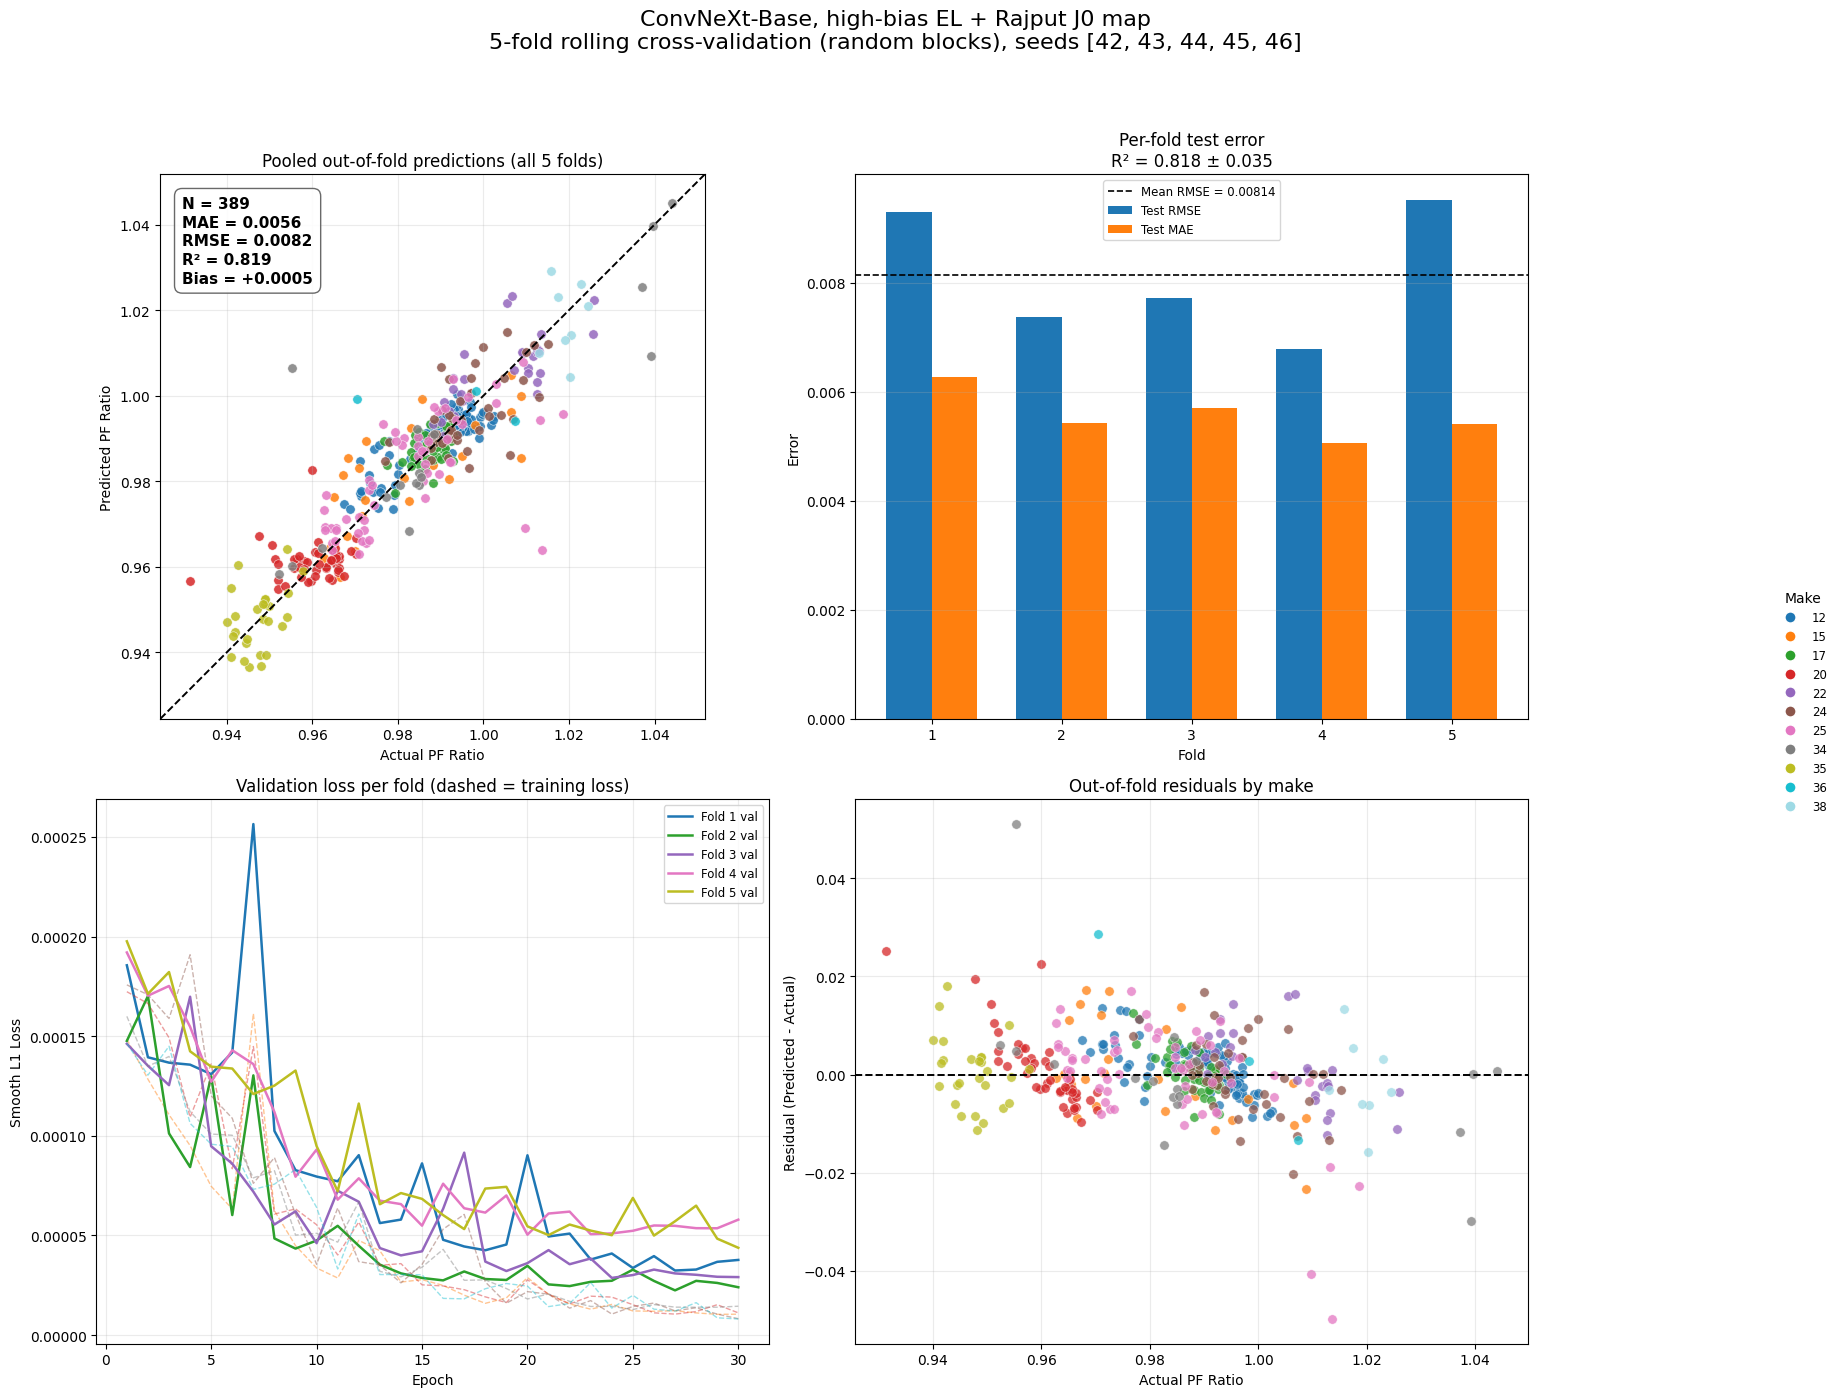


Saved:
- cv5_convnext_base_highbias_j0_fold_assignments.csv
- cv5_convnext_base_highbias_j0_config.json
- cv5_convnext_base_highbias_j0_cv_summary.png
- cv5_convnext_base_highbias_j0_per_fold_metrics.csv
- cv5_convnext_base_highbias_j0_summary_metrics.csv
- cv5_convnext_base_highbias_j0_oof_test_predictions.csv
- cv5_convnext_base_highbias_j0_all_validation_predictions.csv
- cv5_convnext_base_highbias_j0_training_history.csv
- cv5_convnext_base_highbias_j0_oof_metrics_per_make.csv
- cv5_convnext_base_highbias_j0_fold1..5_best_val_model.pth
Cleanup done.


In [2]:
"""
5-fold rolling cross-validation
ConvNeXt-Base, 2-channel input: high-bias EL + Rajput J0 map

Key properties
--------------
1. All images and J0 maps are read from disk and resized ONCE into a single
   RAM cache. Every fold reuses that cache by index, so there is no repeated
   file I/O between folds.

2. Rolling fold scheme with 5 blocks B0..B4:
       fold 1: test = B0, val = B1, train = B2,B3,B4
       fold 2: test = B1, val = B2, train = B3,B4,B0
       fold 3: test = B2, val = B3, train = B4,B0,B1
       fold 4: test = B3, val = B4, train = B0,B1,B2
       fold 5: test = B4, val = B0, train = B1,B2,B3
   Every module is used exactly once as a test sample, so the pooled
   out-of-fold (OOF) prediction set covers the whole dataset.

3. The block partition is controlled by FOLD_ASSIGNMENT_SEED and is written to
   a CSV. The training seed varies per fold (TRAINING_SEEDS) and only affects
   weight init, augmentation and batch order, never the split.

4. J0 normalization limits are recomputed from the TRAIN subset of each fold
   only. The cache stores raw (unnormalized) J0, so this is leak-free and fast.

Reusing the folds for the high-bias-only experiment
---------------------------------------------------
Run this script once. It writes:

    cv5_convnext_base_highbias_j0_fold_assignments.csv

with columns sample_uid, ELHPath, Make, pf_ratio, block, fold_1_split ...
fold_5_split. In the high-bias-only script, read that CSV and select rows with
fold_k_split == "train"/"val"/"test" for fold k. Same modules, same splits,
same seeds, so the two input representations are directly comparable.
"""

import os
import math
import copy
import random
import time
import gc
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"

PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
NUM_WORKERS = 0

# Mixed precision. Keep False to reproduce the existing single-split numbers
# exactly. Setting True roughly halves ConvNeXt memory and speeds up the five
# folds noticeably, at the cost of small numerical differences.
USE_AMP = False

# ---- Cross-validation settings ----
N_FOLDS = 5

# Controls the block partition ONLY. Keep this fixed so the high-bias-only
# experiment can reuse identical folds.
FOLD_ASSIGNMENT_SEED = 42

# Training seed per fold: weight init, augmentation, batch order.
TRAINING_SEEDS = [42, 43, 44, 45, 46]

# Set to None for a plain random block partition (matches the previous
# random 80/10/10 protocol).
# Set to "Make" (or a model-level column, if you have one) for a group-aware
# partition, where all modules of a manufacturer land in the same block. This
# removes manufacturer-level leakage and usually lowers R2 substantially, but
# it is the honest generalization number.
GROUP_COLUMN = None

# Require a Rajput J0 map to exist. Keep True so the high-bias-only run uses
# exactly the same module population and the comparison is like-for-like.
REQUIRE_J0_MAP = True

J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

OUTPUT_PREFIX = "cv5_convnext_base_highbias_j0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    ELHPath: ./EL/3883_35_1_01272020_80.tiff
    J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff
    fallback ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


def derive_sample_uid(elh_path_str):
    """Stable join key shared with the high-bias-only script."""
    if pd.isna(elh_path_str):
        return None

    filename = os.path.basename(str(elh_path_str).strip())
    name, _ = os.path.splitext(filename)
    return name.rsplit("_", 1)[0]


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)", MAKE_COLUMN]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]
    df["sample_uid"] = df["ELHPath"].apply(derive_sample_uid)

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )
    df["j0_path"] = df["ELHPath"].apply(lambda p: derive_j0_path(p, base_dir))

    df = df[df["high_path"].notna()].copy()
    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(lambda p: bool(p) and os.path.exists(p))

    total_before = len(df)

    if REQUIRE_J0_MAP:
        df = df[df["high_exists"] & df["j0_exists"]].copy()
    else:
        df = df[df["high_exists"]].copy()

    print(f"Rows with valid power data: {total_before}")
    print(f"Rows kept after file existence filtering: {len(df)}")
    print(f"Rows removed: {total_before - len(df)}")

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        "sample_uid",
        "ELHPath",
        MAKE_COLUMN,
        "make_plot",
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# FOLD CONSTRUCTION
# =========================================================
def build_rolling_blocks(df, n_folds, fold_seed, group_column=None):
    """
    Assign every row to one of n_folds blocks.

    group_column=None  -> random balanced blocks
    group_column set   -> all rows of a group go to the same block, blocks
                          balanced greedily by sample count
    """
    n = len(df)
    rng = np.random.default_rng(fold_seed)
    block_of_row = np.full(n, -1, dtype=int)

    if group_column is None:
        order = rng.permutation(n)
        for b, idx in enumerate(np.array_split(order, n_folds)):
            block_of_row[idx] = b
        return block_of_row

    if group_column not in df.columns:
        raise ValueError(f"GROUP_COLUMN '{group_column}' not present in dataframe.")

    groups = df[group_column].fillna("Unknown").astype(str).to_numpy()
    uniq, counts = np.unique(groups, return_counts=True)

    perm = rng.permutation(len(uniq))
    uniq, counts = uniq[perm], counts[perm]
    order = np.argsort(-counts, kind="stable")

    load = np.zeros(n_folds, dtype=int)
    group_to_block = {}

    for gi in order:
        b = int(np.argmin(load))
        group_to_block[uniq[gi]] = b
        load[b] += int(counts[gi])

    for i in range(n):
        block_of_row[i] = group_to_block[groups[i]]

    print("\nGroup-aware block sizes:", load.tolist())
    return block_of_row


def fold_indices(block_of_row, fold_index, n_folds):
    """fold_index is 0-based. test = block k, val = block k+1, train = rest."""
    test_block = fold_index
    val_block = (fold_index + 1) % n_folds

    test_idx = np.where(block_of_row == test_block)[0]
    val_idx = np.where(block_of_row == val_block)[0]
    train_idx = np.where(
        (block_of_row != test_block) & (block_of_row != val_block)
    )[0]

    return train_idx, val_idx, test_idx


def build_fold_assignment_table(df, block_of_row, n_folds):
    table = df[["sample_uid", "ELHPath", MAKE_COLUMN, "pf_ratio"]].copy()
    table["block"] = block_of_row

    for k in range(n_folds):
        train_idx, val_idx, test_idx = fold_indices(block_of_row, k, n_folds)

        col = np.empty(len(df), dtype=object)
        col[train_idx] = "train"
        col[val_idx] = "val"
        col[test_idx] = "test"

        table[f"fold_{k + 1}_split"] = col
        table[f"fold_{k + 1}_seed"] = TRAINING_SEEDS[k]

    return table


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")
    return img


def read_physics_map(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)
    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def _resize_with_padding(img, target_size, dtype):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=dtype)
    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_uint8(img, target_size=224):
    return _resize_with_padding(img, target_size, np.uint8)


def resize_with_padding_float(img, target_size=224):
    return _resize_with_padding(img, target_size, np.float32)


J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)


def compute_j0_limits_from_cache(
    cache_j0,
    train_indices,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
    seed=42,
):
    """
    Robust log-domain J0 limits from the TRAIN subset of this fold only.
    Operates on the RAM cache, so no file re-reading between folds.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    """
    all_log_values = []
    rng = np.random.default_rng(seed)

    for i in train_indices:
        j0_resized = cache_j0[i]
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in this fold's train set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(
        f"  log10(J0) p{lower_percentile:g} = {log_lower:.4f} "
        f"({10 ** log_lower:.3e} A/px) | "
        f"p{upper_percentile:g} = {log_upper:.4f} "
        f"({10 ** log_upper:.3e} A/px) | "
        f"active px = {all_log_values.size:,}"
    )

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization using this fold's training limits.

    Background/invalid pixels (<= floor) map to exactly 0.0 so the network can
    still distinguish "no cell" from "low-J0 cell". Active pixels are log10
    scaled, clipped to the training percentile band, then mapped into (0, 1].
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10 ** log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# MASTER RAM CACHE (loaded once, shared by all folds)
# =========================================================
class MasterCache:
    def __init__(self, dataframe, image_size=224):
        self.image_size = image_size
        n = len(dataframe)

        expected_mb = (
            n * image_size * image_size * 1 + n * image_size * image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM (once, shared by all folds)...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.high = np.empty((n, image_size, image_size), dtype=np.uint8)
        self.j0 = np.empty((n, image_size, image_size), dtype=np.float32)
        self.pf = dataframe["pf_ratio"].to_numpy(dtype=np.float32)

        failed = 0

        for i in range(n):
            row = dataframe.iloc[i]
            try:
                self.high[i] = resize_with_padding_uint8(
                    read_high_bias_image(row["high_path"]), image_size
                )
                self.j0[i] = resize_with_padding_float(
                    read_physics_map(row["j0_path"]), image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.high[i] = 0
                self.j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.high.nbytes + self.j0.nbytes) / (1024 ** 2)

        print(f"Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}")


class FoldSubsetDataset(Dataset):
    """Views into the master cache. No file I/O, no image copies at build time."""

    def __init__(self, master, indices, augment=False, j0_norm_params=None):
        self.master = master
        self.indices = np.asarray(indices, dtype=int)
        self.augment = augment
        self.j0_norm_params = j0_norm_params

        if j0_norm_params is None:
            raise ValueError("j0_norm_params must be provided for each fold.")

    def __len__(self):
        return len(self.indices)

    def apply_same_augmentation(self, high_img, j0_map):
        """Identical geometric flips so image and J0 map stay aligned."""
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __getitem__(self, i):
        idx = self.indices[i]

        high_img = self.master.high[idx].copy()
        j0_map = self.master.j0[idx].copy()

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, fold-train log-domain normalization.
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        x = np.concatenate(
            [np.expand_dims(high_img, 0), np.expand_dims(j0_map, 0)], axis=0
        )
        y = float(self.master.pf[idx])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using fold-train limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem: model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier: LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device, use_amp=False):
    model.eval()

    running_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            if use_amp:
                with torch.autocast(device_type=device.type, dtype=torch.float16):
                    outputs = model(inputs)
                outputs = outputs.float()
            else:
                outputs = model(inputs)

            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# ONE FOLD
# =========================================================
def run_one_fold(fold_index, df, master, block_of_row):
    fold_number = fold_index + 1
    seed = TRAINING_SEEDS[fold_index]

    train_idx, val_idx, test_idx = fold_indices(block_of_row, fold_index, N_FOLDS)

    print(f"\n{'=' * 78}")
    print(f"FOLD {fold_number}/{N_FOLDS} | ConvNeXt-Base | training seed = {seed}")
    print(
        f"test block = {fold_index} ({len(test_idx)}) | "
        f"val block = {(fold_index + 1) % N_FOLDS} ({len(val_idx)}) | "
        f"train ({len(train_idx)})"
    )
    print(f"{'=' * 78}")

    if min(len(train_idx), len(val_idx), len(test_idx)) == 0:
        raise ValueError(f"Fold {fold_number} has an empty split.")

    set_seed(seed)

    j0_norm_params = compute_j0_limits_from_cache(
        master.j0,
        train_idx,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
        seed=seed,
    )

    train_dataset = FoldSubsetDataset(master, train_idx, True, j0_norm_params)
    val_dataset = FoldSubsetDataset(master, val_idx, False, j0_norm_params)
    test_dataset = FoldSubsetDataset(master, test_idx, False, j0_norm_params)

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    if fold_number == 1:
        print(f"  Backbone parameters: {sum(p.numel() for p in backbone_params):,}")
        print(f"  Head parameters:     {sum(p.numel() for p in head_params):,}")
        print(f"  Total parameters:    {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    use_amp = USE_AMP and DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    history = []
    t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)

        train_eval_loss, _, _, _, _, _ = evaluate(
            model, train_loader, criterion, DEVICE, use_amp
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE, use_amp
        )
        test_loss, _, _, _, _, _ = evaluate(
            model, test_loader, criterion, DEVICE, use_amp
        )

        scheduler.step(val_loss)

        history.append(
            {
                "fold": fold_number,
                "seed": seed,
                "epoch": epoch + 1,
                "train_loss": train_eval_loss,
                "validation_loss": val_loss,
                "test_loss": test_loss,
                "backbone_lr": current_backbone_lr,
                "head_lr": current_head_lr,
            }
        )

        print(
            f"  Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{time.time() - epoch_t0:.1f}s | "
            f"Train {train_eval_loss:.6f} | "
            f"Val {val_loss:.6f} | "
            f"Test {test_loss:.6f} | "
            f"Val MAE {val_mae:.6f} | "
            f"Val RMSE {val_rmse:.6f} | "
            f"Val R2 {val_r2:.4f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    fold_seconds = time.time() - t0
    print(
        f"  Fold time: {fold_seconds:.1f}s ({fold_seconds / 60:.1f} min) | "
        f"best epoch: {best_epoch}"
    )

    model.load_state_dict(best_model_wts)

    _, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE, use_amp
    )
    _, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE, use_amp
    )

    print(
        f"  VAL  MAE {val_mae:.6f} | RMSE {val_rmse:.6f} | R2 {val_r2:.6f}\n"
        f"  TEST MAE {test_mae:.6f} | RMSE {test_rmse:.6f} | R2 {test_r2:.6f}"
    )

    history_df = pd.DataFrame(history)
    history_df["is_best_epoch"] = history_df["epoch"] == best_epoch

    def prediction_table(indices, trues, preds, split_name):
        table = df.iloc[indices].reset_index(drop=True).copy()
        table["fold"] = fold_number
        table["seed"] = seed
        table["evaluation_split"] = split_name
        table["actual_pf_ratio"] = trues
        table["predicted_pf_ratio"] = preds
        table["residual"] = preds - trues
        table["absolute_error"] = np.abs(preds - trues)
        return table

    test_table = prediction_table(test_idx, test_trues, test_preds, "test")
    val_table = prediction_table(val_idx, val_trues, val_preds, "validation")

    model_path = f"{OUTPUT_PREFIX}_fold{fold_number}_best_val_model.pth"
    torch.save(model.state_dict(), model_path)

    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    fold_metrics = {
        "fold": fold_number,
        "seed": seed,
        "best_epoch": best_epoch,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
        "val_MAE": val_mae,
        "val_RMSE": val_rmse,
        "val_R2": val_r2,
        "test_MAE": test_mae,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "j0_log_lower": j0_norm_params["log_lower"],
        "j0_log_upper": j0_norm_params["log_upper"],
        "model_path": model_path,
    }

    return fold_metrics, history_df, test_table, val_table


# =========================================================
# PLOTTING
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]
    return dict(zip(makes, colours))


def plot_oof_scatter(ax, oof_df, make_palette):
    values = np.concatenate(
        [oof_df["actual_pf_ratio"].to_numpy(), oof_df["predicted_pf_ratio"].to_numpy()]
    )
    minimum, maximum = float(values.min()), float(values.max())
    margin = max((maximum - minimum) * 0.06, 0.003)
    minimum, maximum = minimum - margin, maximum + margin

    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=46,
            color=make_palette[make_value],
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
            label=make_value,
        )

    ax.plot([minimum, maximum], [minimum, maximum], "--", color="black", linewidth=1.4)
    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title("Pooled out-of-fold predictions (all 5 folds)")
    ax.grid(True, alpha=0.25)

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    text = (
        f"N = {len(actual)}\n"
        f"MAE = {mean_absolute_error(actual, predicted):.4f}\n"
        f"RMSE = {math.sqrt(mean_squared_error(actual, predicted)):.4f}\n"
        f"R² = {r2_score(actual, predicted):.3f}\n"
        f"Bias = {np.mean(predicted - actual):+.4f}"
    )

    ax.text(
        0.04, 0.96, text, transform=ax.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold", linespacing=1.3,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.35", alpha=0.9),
    )


def plot_fold_metric_bars(ax, metrics_df):
    folds = metrics_df["fold"].to_numpy()
    width = 0.35

    ax.bar(folds - width / 2, metrics_df["test_RMSE"], width, label="Test RMSE")
    ax.bar(folds + width / 2, metrics_df["test_MAE"], width, label="Test MAE")

    ax.axhline(
        metrics_df["test_RMSE"].mean(), linestyle="--", color="black", linewidth=1.2,
        label=f"Mean RMSE = {metrics_df['test_RMSE'].mean():.5f}",
    )

    ax.set_xticks(folds)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_title(
        "Per-fold test error\n"
        f"R² = {metrics_df['test_R2'].mean():.3f} ± {metrics_df['test_R2'].std(ddof=1):.3f}"
    )
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend(fontsize=8.5)


def plot_all_fold_losses(ax, history_df):
    for fold_number, group in history_df.groupby("fold"):
        ax.plot(
            group["epoch"], group["validation_loss"],
            linewidth=1.8, label=f"Fold {fold_number} val",
        )
        ax.plot(
            group["epoch"], group["train_loss"],
            linewidth=1.0, alpha=0.45, linestyle="--",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Validation loss per fold (dashed = training loss)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8.5)


def plot_oof_residuals(ax, oof_df, make_palette):
    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"], group["residual"],
            color=make_palette[make_value], s=46, alpha=0.75,
            edgecolors="white", linewidths=0.4,
        )

    ax.axhline(0.0, linestyle="--", color="black", linewidth=1.4)
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Out-of-fold residuals by make")
    ax.grid(True, alpha=0.25)


def calculate_metrics_per_make(results_df):
    rows = []
    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < N_FOLDS * 4:
        raise ValueError(f"Only {len(df)} samples available, too few for {N_FOLDS} folds.")

    print("\nSample rows:")
    print(df.head())

    # ---- Folds first, so the assignment CSV exists even if training crashes ----
    block_of_row = build_rolling_blocks(
        df, N_FOLDS, FOLD_ASSIGNMENT_SEED, GROUP_COLUMN
    )

    fold_table = build_fold_assignment_table(df, block_of_row, N_FOLDS)
    fold_csv_path = f"{OUTPUT_PREFIX}_fold_assignments.csv"
    fold_table.to_csv(fold_csv_path, index=False)

    print(f"\nFold assignment written to {fold_csv_path}")
    print("Block sizes:", np.bincount(block_of_row, minlength=N_FOLDS).tolist())

    for k in range(N_FOLDS):
        counts = fold_table[f"fold_{k + 1}_split"].value_counts()
        print(
            f"  Fold {k + 1}: "
            f"train={counts.get('train', 0)}, "
            f"val={counts.get('val', 0)}, "
            f"test={counts.get('test', 0)}, "
            f"seed={TRAINING_SEEDS[k]}"
        )

    config = {
        "architecture": "convnext_base",
        "csv_path": CSV_PATH,
        "n_folds": N_FOLDS,
        "fold_assignment_seed": FOLD_ASSIGNMENT_SEED,
        "training_seeds": TRAINING_SEEDS,
        "group_column": GROUP_COLUMN,
        "require_j0_map": REQUIRE_J0_MAP,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "backbone_lr": BACKBONE_LR,
        "use_amp": USE_AMP,
        "n_samples": int(len(df)),
    }

    with open(f"{OUTPUT_PREFIX}_config.json", "w") as fh:
        json.dump(config, fh, indent=2)

    # ---- Single RAM preload shared by every fold ----
    master = MasterCache(df, image_size=IMAGE_SIZE)

    all_metrics = []
    all_history = []
    all_test_tables = []
    all_val_tables = []

    total_t0 = time.time()

    for fold_index in range(N_FOLDS):
        metrics, history_df, test_table, val_table = run_one_fold(
            fold_index, df, master, block_of_row
        )

        all_metrics.append(metrics)
        all_history.append(history_df)
        all_test_tables.append(test_table)
        all_val_tables.append(val_table)

        # incremental save, so a crash on a later fold does not lose earlier work
        pd.DataFrame(all_metrics).to_csv(
            f"{OUTPUT_PREFIX}_per_fold_metrics_partial.csv", index=False
        )

    total_time = time.time() - total_t0
    print(f"\nAll folds complete in {total_time / 60:.1f} min")

    metrics_df = pd.DataFrame(all_metrics)
    history_df = pd.concat(all_history, ignore_index=True)
    oof_df = pd.concat(all_test_tables, ignore_index=True)
    val_df_all = pd.concat(all_val_tables, ignore_index=True)

    # ---- Summary ----
    print(f"\n{'=' * 78}")
    print("CROSS-VALIDATION SUMMARY (test folds)")
    print(f"{'=' * 78}")
    print(metrics_df[["fold", "seed", "best_epoch",
                      "test_MAE", "test_RMSE", "test_R2"]].to_string(index=False))

    summary_rows = []
    for metric in ["test_MAE", "test_RMSE", "test_R2", "val_MAE", "val_RMSE", "val_R2"]:
        values = metrics_df[metric].to_numpy()
        summary_rows.append(
            {
                "metric": metric,
                "mean": float(np.mean(values)),
                "std": float(np.std(values, ddof=1)),
                "min": float(np.min(values)),
                "max": float(np.max(values)),
            }
        )

    summary_df = pd.DataFrame(summary_rows)

    print("\nMean ± std across folds:")
    for _, row in summary_df.iterrows():
        print(f"  {row['metric']:<10} {row['mean']:.6f} ± {row['std']:.6f}")

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    pooled = {
        "metric": "pooled_out_of_fold",
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(predicted - actual)),
    }

    print(
        f"\nPooled out-of-fold (N={pooled['N']}): "
        f"MAE {pooled['MAE']:.6f} | RMSE {pooled['RMSE']:.6f} | R2 {pooled['R2']:.6f}"
    )

    # ---- Figure ----
    make_palette = build_make_palette(df["make_plot"])

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_oof_scatter(axes[0, 0], oof_df, make_palette)
    plot_fold_metric_bars(axes[0, 1], metrics_df)
    plot_all_fold_losses(axes[1, 0], history_df)
    plot_oof_residuals(axes[1, 1], oof_df, make_palette)

    make_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=make_palette[m], markeredgecolor="white",
               markersize=8, label=m)
        for m in sorted(make_palette)
    ]

    fig.legend(
        handles=make_handles, loc="center left", bbox_to_anchor=(0.985, 0.5),
        frameon=False, title="Make", fontsize=8.5,
    )

    split_mode = "group-aware" if GROUP_COLUMN else "random"
    fig.suptitle(
        f"ConvNeXt-Base, high-bias EL + Rajput J0 map\n"
        f"{N_FOLDS}-fold rolling cross-validation ({split_mode} blocks), "
        f"seeds {TRAINING_SEEDS}",
        fontsize=16, y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    fig_path = f"{OUTPUT_PREFIX}_cv_summary.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_PREFIX}_cv_summary.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    per_fold_path = f"{OUTPUT_PREFIX}_per_fold_metrics.csv"
    summary_path = f"{OUTPUT_PREFIX}_summary_metrics.csv"
    oof_path = f"{OUTPUT_PREFIX}_oof_test_predictions.csv"
    val_path = f"{OUTPUT_PREFIX}_all_validation_predictions.csv"
    history_path = f"{OUTPUT_PREFIX}_training_history.csv"
    make_path = f"{OUTPUT_PREFIX}_oof_metrics_per_make.csv"

    metrics_df.to_csv(per_fold_path, index=False)
    pd.concat(
        [summary_df, pd.DataFrame([pooled])], ignore_index=True
    ).to_csv(summary_path, index=False)
    oof_df.to_csv(oof_path, index=False)
    val_df_all.to_csv(val_path, index=False)
    history_df.to_csv(history_path, index=False)
    calculate_metrics_per_make(oof_df).to_csv(make_path, index=False)

    print("\nSaved:")
    for path in [
        fold_csv_path, f"{OUTPUT_PREFIX}_config.json", fig_path, per_fold_path,
        summary_path, oof_path, val_path, history_path, make_path,
    ]:
        print(f"- {path}")

    print(f"- {OUTPUT_PREFIX}_fold1..{N_FOLDS}_best_val_model.pth")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
